In [3]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

df = pd.read_csv('D:/FreeUni/Semester_6/Machine Learning/house_prices/ml_assn/ml_assn_01/data/train.csv')

In [4]:
df.shape

(1460, 81)

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_train.shape, X_test.shape

((1168, 80), (292, 80))

In [8]:
print(y_train.describe())

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64


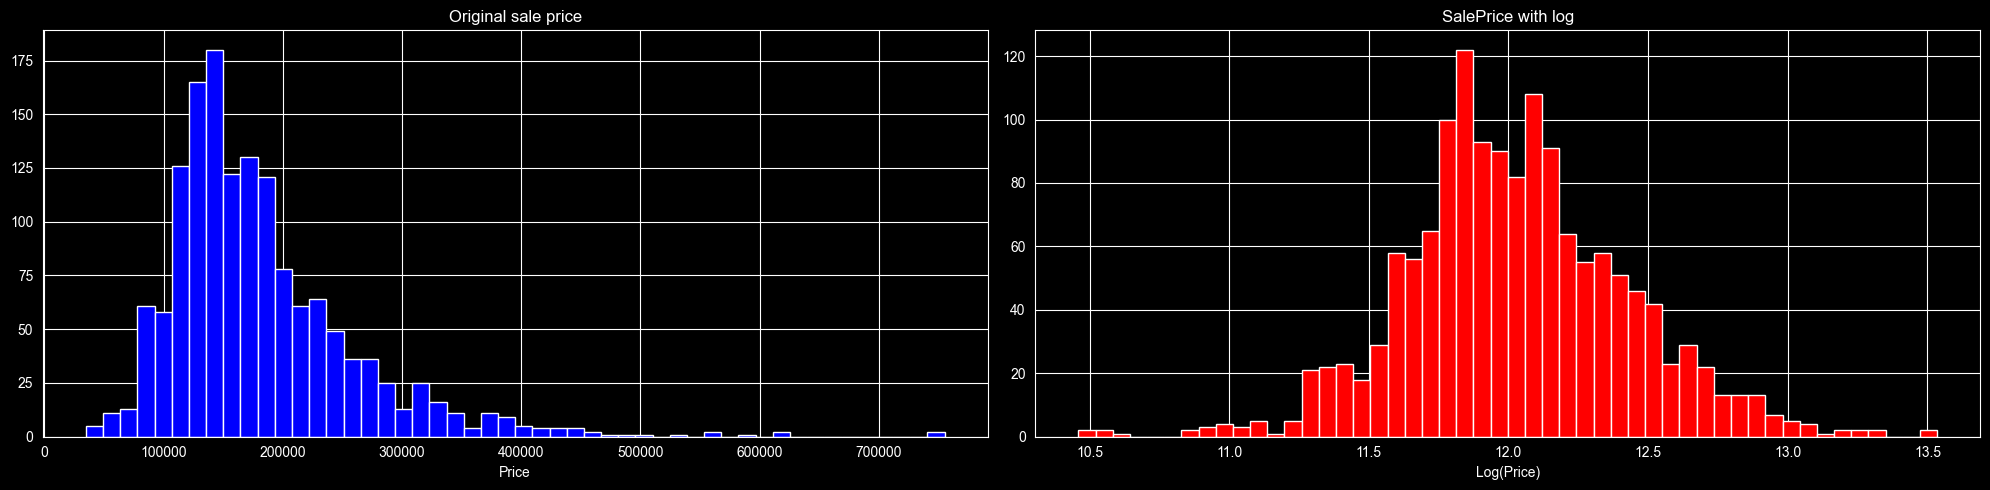

In [9]:
import matplotlib.pyplot as plt

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# distribution of sale prices
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

axes[0].hist(y, bins=50, color='blue')
axes[0].set_title('Original sale price')
axes[0].set_xlabel('Price')

axes[1].hist(np.log1p(y), bins=50, color='red')
axes[1].set_title('SalePrice with log')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.show()

# Data Cleaning

In [10]:
X_train.isna().mean()

Id               0.000000
MSSubClass       0.000000
MSZoning         0.000000
LotFrontage      0.185788
LotArea          0.000000
                   ...   
MiscVal          0.000000
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
Length: 80, dtype: float64

In [11]:
X_test.isna().mean()

Id               0.000000
MSSubClass       0.000000
MSZoning         0.000000
LotFrontage      0.143836
LotArea          0.000000
                   ...   
MiscVal          0.000000
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
Length: 80, dtype: float64

In [12]:
train_ids = X_train.pop('Id')
test_ids = X_test.pop('Id')

In [13]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(" ")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
 
Numerical columns (36): ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars'

In [14]:
for col in cat_cols:
    print(X_train[col].value_counts())

MSZoning
RL         924
RM         172
FV          53
RH          15
C (all)      4
Name: count, dtype: int64
Street
Pave    1164
Grvl       4
Name: count, dtype: int64
Alley
Grvl    44
Pave    30
Name: count, dtype: int64
LotShape
Reg    729
IR1    394
IR2     37
IR3      8
Name: count, dtype: int64
LandContour
Lvl    1059
Bnk      48
HLS      35
Low      26
Name: count, dtype: int64
Utilities
AllPub    1167
NoSeWa       1
Name: count, dtype: int64
LotConfig
Inside     822
Corner     221
CulDSac     84
FR2         38
FR3          3
Name: count, dtype: int64
LandSlope
Gtl    1108
Mod      51
Sev       9
Name: count, dtype: int64
Neighborhood
NAmes      181
CollgCr    115
OldTown     91
Edwards     87
Somerst     69
NWAmes      66
Gilbert     65
NridgHt     61
Sawyer      58
BrkSide     45
Crawfor     44
SawyerW     44
Mitchel     40
NoRidge     33
Timber      28
IDOTRR      26
SWISU       21
StoneBr     20
ClearCr     19
Blmngtn     15
BrDale      13
MeadowV     10
Veenker      9
NPkVi

In [15]:
missing = pd.DataFrame({
    'missing_count': X_train.isnull().sum(),
    'missing_%': (X_train.isnull().sum() / len(X_train) * 100).round(1),
    'dtype': X_train.dtypes
})

missing = missing[missing['missing_count'] > 0].sort_values('missing_%', ascending=False)
print(missing)

              missing_count  missing_%    dtype
PoolQC                 1162       99.5   object
MiscFeature            1122       96.1   object
Alley                  1094       93.7   object
Fence                   935       80.1   object
MasVnrType              683       58.5   object
FireplaceQu             547       46.8   object
LotFrontage             217       18.6  float64
GarageType               64        5.5   object
GarageYrBlt              64        5.5  float64
GarageFinish             64        5.5   object
GarageQual               64        5.5   object
GarageCond               64        5.5   object
BsmtCond                 28        2.4   object
BsmtFinType1             28        2.4   object
BsmtExposure             28        2.4   object
BsmtQual                 28        2.4   object
BsmtFinType2             28        2.4   object
MasVnrArea                6        0.5  float64
Electrical                1        0.1   object


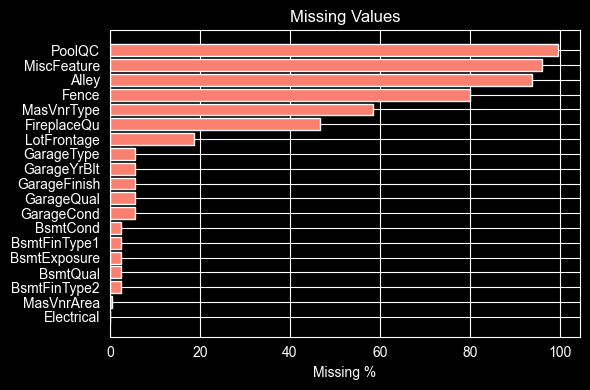

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(missing.index, missing['missing_%'], color='salmon')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
def find_medians_mode(X_train):
    params = {
        'neighborhood_medians': X_train.groupby('Neighborhood')['LotFrontage'].median(),
        'electrical_mode': X_train['Electrical'].mode()[0]
    }
    return params

def fill_missing_values(X, params):
    X = X.copy()

    none_columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
                    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtCond',
                    'BsmtFinType1', 'BsmtExposure', 'BsmtQual', 'BsmtFinType2']

    for column in none_columns:
            X[column] = X[column].fillna('None')


    X['GarageYrBlt'] = X['GarageYrBlt'].fillna(0)

    X['MasVnrArea'] = X['MasVnrArea'].fillna(0)

    X['LotFrontage'] = X['LotFrontage'].fillna(X['Neighborhood'].map(params['neighborhood_medians']))
    X['LotFrontage'] = X['LotFrontage'].fillna(params['neighborhood_medians'].median())

    X['Electrical'] = X['Electrical'].fillna(params['electrical_mode'])

    return X

In [18]:
params = find_medians_mode(X_train)

X_train = fill_missing_values(X_train, params)
X_test  = fill_missing_values(X_test, params)

In [19]:
remaining_train = X_train.isnull().sum()
remaining_train = remaining_train[remaining_train > 0]

remaining_test = X_test.isnull().sum()
remaining_test = remaining_test[remaining_test > 0]

if len(remaining_train) > 0:
    print("Still remaining null values in the train set")
else:
    print("No null values in the train set")

if len(remaining_test) > 0:
    print("Still remaining null values in the test set")
else:
    print("No null values in the test set")

No null values in the train set
No null values in the test set


In [20]:
print(cat_cols)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


# Feature Engineering

In [21]:
neighborhood_means = y_train.groupby(X_train['Neighborhood']).mean()

In [22]:
def ordinal_encode(X):
    quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
    quality_cols = ['GarageQual', 'GarageCond', 'PoolQC', 'ExterQual',
                    'ExterCond', 'BsmtCond', 'HeatingQC',
                    'KitchenQual', 'BsmtQual', 'FireplaceQu']

    for col in quality_cols:
        if col in X.columns:
            X[col] = X[col].map(quality_map)

    X['BsmtExposure'] = X['BsmtExposure'].map(
        {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})

    bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
    X['BsmtFinType1'] = X['BsmtFinType1'].map(bsmt_fin_map)
    X['BsmtFinType2'] = X['BsmtFinType2'].map(bsmt_fin_map)

    X['GarageFinish'] = X['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})
    X['Fence'] = X['Fence'].map({'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4})
    X['Functional'] = X['Functional'].map(
        {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8})
    X['PavedDrive'] = X['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})
    X['LandSlope'] = X['LandSlope'].map({'Sev': 1, 'Mod': 2, 'Gtl': 3})
    X['LotShape'] = X['LotShape'].map({'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4})

    return X

In [23]:
X_train = ordinal_encode(X_train.copy())
X_train['Neighborhood'] = X_train['Neighborhood'].map(neighborhood_means).fillna(neighborhood_means.mean())
X_train['MSSubClass'] = X_train['MSSubClass'].astype(str)

ohe_columns = [col for col in X_train.columns if X_train[col].dtype == 'object']
X_train = pd.get_dummies(X_train, columns=ohe_columns, dtype=int)
fitted_columns = X_train.columns.tolist()

In [24]:
X_test = ordinal_encode(X_test.copy())
X_test['Neighborhood'] = X_test['Neighborhood'].map(neighborhood_means).fillna(neighborhood_means.mean())
X_test['MSSubClass'] = X_test['MSSubClass'].astype(str)

X_test = pd.get_dummies(X_test, columns=ohe_columns, dtype=int)

for col in fitted_columns:
    if col not in X_test.columns:
        X_test[col] = 0

X_test = X_test[fitted_columns]

In [25]:
print(X_train.shape)
print(X_test.shape)

(1168, 214)
(292, 214)


In [26]:
import mlflow
import dagshub

dagshub.init(repo_owner='aochi23', repo_name='ml_assn_01', mlflow=True)

Accessing as aochi23

Initialized MLflow to track repo "aochi23/ml_assn_01"

Repository aochi23/ml_assn_01 initialized!

# Feature Selection

In [27]:
near_constant_cols = []
for col in X_train.columns:
    top_freq = X_train[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        near_constant_cols.append(col)

X_train = X_train.drop(columns=near_constant_cols)
X_test  = X_test.drop(columns=near_constant_cols)

print(near_constant_cols)
print(f"Dropped {len(near_constant_cols)} near-constant columns")

['LowQualFinSF', 'KitchenAbvGr', '3SsnPorch', 'PoolArea', 'PoolQC', 'MiscVal', 'MSSubClass_160', 'MSSubClass_180', 'MSSubClass_190', 'MSSubClass_30', 'MSSubClass_40', 'MSSubClass_45', 'MSSubClass_70', 'MSSubClass_75', 'MSSubClass_80', 'MSSubClass_85', 'MSSubClass_90', 'MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RH', 'Street_Grvl', 'Street_Pave', 'Alley_Grvl', 'Alley_Pave', 'LandContour_Bnk', 'LandContour_HLS', 'LandContour_Low', 'Utilities_AllPub', 'Utilities_NoSeWa', 'LotConfig_FR2', 'LotConfig_FR3', 'Condition1_Artery', 'Condition1_PosA', 'Condition1_PosN', 'Condition1_RRAe', 'Condition1_RRAn', 'Condition1_RRNe', 'Condition1_RRNn', 'Condition2_Artery', 'Condition2_Feedr', 'Condition2_Norm', 'Condition2_PosA', 'Condition2_PosN', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'HouseStyle_1.5Unf', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_SFoyer', 'HouseStyle_SLvl', 'RoofStyle_Flat', 'RoofStyle_Gambrel', 'Roo

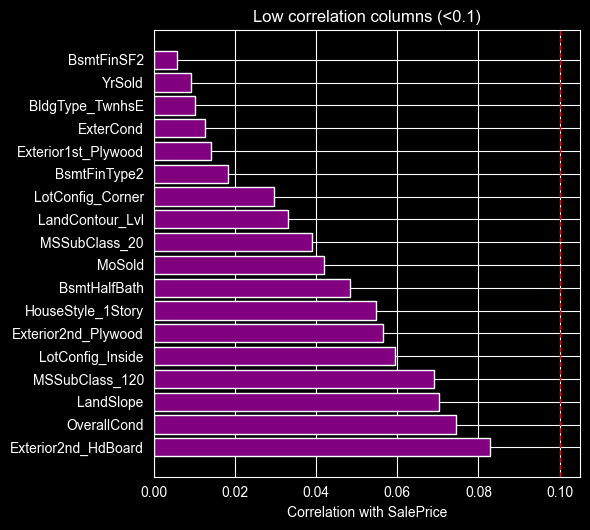

['BsmtFinSF2', 'YrSold', 'BldgType_TwnhsE', 'ExterCond', 'Exterior1st_Plywood', 'BsmtFinType2', 'LotConfig_Corner', 'LandContour_Lvl', 'MSSubClass_20', 'MoSold', 'BsmtHalfBath', 'HouseStyle_1Story', 'Exterior2nd_Plywood', 'LotConfig_Inside', 'MSSubClass_120', 'LandSlope', 'OverallCond', 'Exterior2nd_HdBoard']


In [28]:
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()
correlations = X_train[num_cols].corrwith(y_train).abs().sort_values(ascending=False)
low_corr = correlations[correlations < 0.1].sort_values()

fig, ax = plt.subplots(figsize=(6, max(3, len(low_corr) * 0.3)))
ax.barh(low_corr.index, low_corr.values, color='purple')
ax.axvline(0.1, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Correlation with SalePrice')
ax.set_title('Low correlation columns (<0.1)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(low_corr.index.tolist())

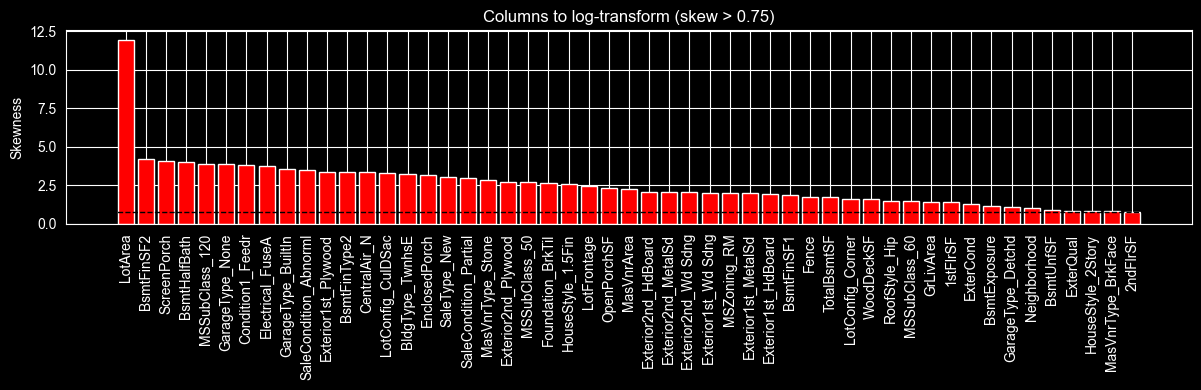

In [29]:
from matplotlib import pyplot as plt

num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

skewness = X_train[num_cols].skew().sort_values(ascending=False)
high_skew = skewness[skewness > 0.75].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(high_skew.index, high_skew.values, color='red')
ax.axhline(0.75, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Skewness')
ax.set_title('Columns to log-transform (skew > 0.75)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

for col in high_skew.index:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

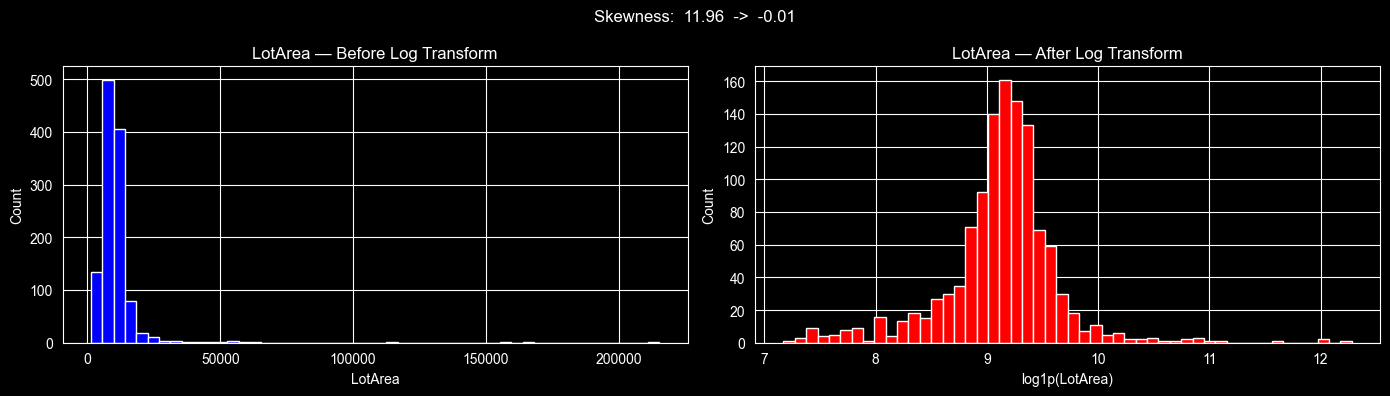

In [30]:
lot_area_original = np.expm1(X_train['LotArea'])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(lot_area_original, bins=50, color='blue', edgecolor='white')
axes[0].set_title('LotArea — Before Log Transform')
axes[0].set_xlabel('LotArea')
axes[0].set_ylabel('Count')

axes[1].hist(X_train['LotArea'], bins=50, color='red', edgecolor='white')
axes[1].set_title('LotArea — After Log Transform')
axes[1].set_xlabel('log1p(LotArea)')
axes[1].set_ylabel('Count')

plt.suptitle(f'Skewness:  {lot_area_original.skew():.2f}  ->  {X_train["LotArea"].skew():.2f}', fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
def combine_some_columns(X):
    X['TotalSF']      = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']
    X['TotalBath']    = (X['FullBath'] + X['BsmtFullBath'] +
                         0.5 * X['HalfBath'] + 0.5 * X['BsmtHalfBath'])
    X['TotalPorch']   = (X['OpenPorchSF'] + X['EnclosedPorch'] +
                         X['ScreenPorch'])
    X['HouseAge']     = X['YrSold'] - X['YearBuilt']
    X['RemodAge']     = X['YrSold'] - X['YearRemodAdd']
    X['IsRemodeled']  = (X['YearBuilt'] != X['YearRemodAdd']).astype(int)

    X['HasGarage']    = (X['GarageArea'] > 0).astype(int)
    X['HasFireplace'] = (X['Fireplaces'] > 0).astype(int)
    X['HasPorch']     = (X['TotalPorch'] > 0).astype(int)
    X['HasBsmt']      = (X['TotalBsmtSF'] > 0).astype(int)

    return X

X_train = combine_some_columns(X_train)
X_test = combine_some_columns(X_test)

combined_columns_drop = [
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
    'FullBath', 'BsmtFullBath', 'HalfBath', 'BsmtHalfBath',
    'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch',
    'YearBuilt', 'YearRemodAdd', 'YrSold'
]

X_train = X_train.drop(columns=combined_columns_drop)
X_test  = X_test.drop(columns=combined_columns_drop)

In [33]:
from sklearn.base import BaseEstimator, TransformerMixin

class IVSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.02):
        self.threshold = threshold
        self.iv_scores = {}
        self.selected_features = None
        self.median = None

    def compute_iv(self, X, y_binary, col):
        series = X[col]
        if series.nunique() > 10:
            series = pd.qcut(series, q=10, duplicates='drop')

        df = pd.DataFrame({"col": series, "target": y_binary})
        total_e  = y_binary.sum()
        total_ne = (1 - y_binary).sum()
        iv = 0
        for val, group in df.groupby("col", observed=True):
            e, ne   = group["target"].sum(), (1 - group["target"]).sum()
            dist_e  = (e  + 0.5) / (total_e  + 0.5)
            dist_ne = (ne + 0.5) / (total_ne + 0.5)
            iv     += (dist_e - dist_ne) * np.log(dist_e / dist_ne)

        return iv

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        self.median = y.median()
        y_binary = (y > self.median).astype(int)

        self.iv_scores = {}
        for col in X.columns:
            self.iv_scores[col] = self.compute_iv(X, y_binary, col)

        self.selected_features = [
            col for col, iv in self.iv_scores.items() if iv >= self.threshold
        ]
        #print(f"IVSelector kept: {len(self.selected_features)} features")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.selected_features]

In [34]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.85):
        self.threshold  = threshold
        self.features_to_drop = None
        self.selected_features = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).reset_index(drop=True)
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        self.features_to_drop = set()
        for col in upper.columns:
            if any(upper[col] > self.threshold):
                for partner in upper.index[upper[col] > self.threshold].tolist():
                    if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                        self.features_to_drop.add(col)
                    else:
                        self.features_to_drop.add(partner)

        self.selected_features = [
            col for col in X.columns if col not in self.features_to_drop
        ]
        #print(f"CorrelationFilter dropped: {len(self.features_to_drop)}")
        #print(f"CorrelationFilter kept:    {len(self.selected_features)}")

        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.selected_features]

In [35]:
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFE


class RFESelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_features_to_select=40, estimator=None):
        self.feature_names = None
        self.n_features_to_select = n_features_to_select
        self.estimator = estimator
        self.selected_features = None
        self.rfe = None

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        self.feature_names = list(X.columns)

        est = self.estimator if self.estimator is not None else Ridge(alpha=1.0)
        self.rfe = RFE(estimator=est, n_features_to_select=self.n_features_to_select)
        self.rfe.fit(X, y)

        self.selected_features = [
            f for f, s in zip(self.feature_names, self.rfe.support_) if s
        ]
        #print(f"RFESelector kept: {len(self.selected_features)} features")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        X.columns = self.feature_names

        return X[self.selected_features]

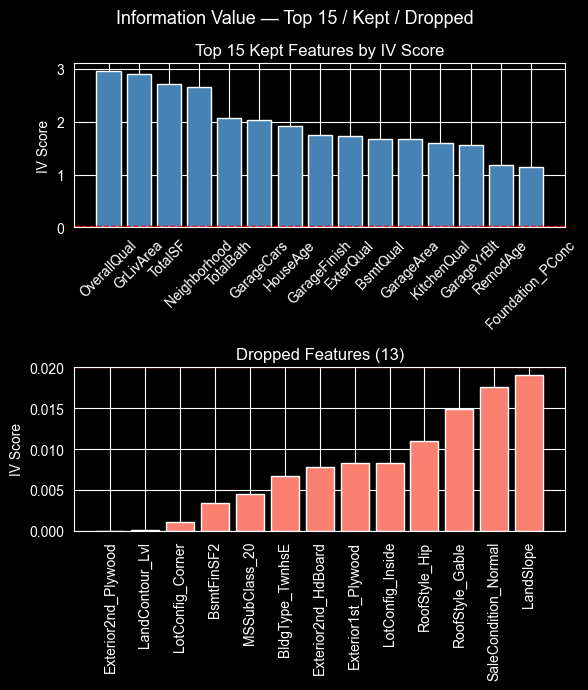

Kept:    82 features
Dropped: 13 features


In [36]:
iv_selector = IVSelector(threshold=0.02)
iv_selector.fit(X_train, y_train_log)

iv_series = pd.Series(iv_selector.iv_scores).sort_values()
kept_iv = iv_series[iv_series >= 0.02]
dropped_iv = iv_series[iv_series <  0.02]
top15 = kept_iv.sort_values(ascending=False).head(15)

fig, axes = plt.subplots(2, 1, figsize=(6, 7))

axes[0].bar(top15.index, top15.values, color='steelblue')
axes[0].axhline(y=0.02, color='red', linestyle='--', linewidth=1)
axes[0].set_ylabel('IV Score')
axes[0].set_title(f'Top 15 Kept Features by IV Score')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(dropped_iv.index, dropped_iv.values, color='salmon')
axes[1].axhline(y=0.02, color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel('IV Score')
axes[1].set_title(f'Dropped Features ({len(dropped_iv)})')
axes[1].tick_params(axis='x', rotation=90)

plt.suptitle('Information Value — Top 15 / Kept / Dropped', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Kept:    {len(kept_iv)} features")
print(f"Dropped: {len(dropped_iv)} features")

Dropped features and their partners:

  GarageCars - GarageArea: 0.88
  MasVnrArea - MasVnrType_None: 0.97
  HasFireplace - Fireplaces: 0.90
  HasFireplace - FireplaceQu: 0.95
  GarageType_None - GarageYrBlt: 1.00
  GarageType_None - GarageQual: 0.94
  GarageType_None - GarageCond: 0.95
  GarageType_None - HasGarage: 1.00
  BsmtFinType2 - BsmtFinSF2: 0.87
  GarageCond - GarageYrBlt: 0.95
  GarageCond - GarageQual: 0.96
  GarageCond - GarageType_None: 0.95
  GarageCond - HasGarage: 0.95
  CentralAir_Y - CentralAir_N: 1.00
  GarageQual - GarageYrBlt: 0.95
  GarageQual - GarageCond: 0.96
  GarageQual - GarageType_None: 0.94
  GarageQual - HasGarage: 0.94
  RoofStyle_Hip - RoofStyle_Gable: 0.93
  FireplaceQu - Fireplaces: 0.86
  FireplaceQu - HasFireplace: 0.95
  Exterior1st_MetalSd - Exterior2nd_MetalSd: 0.97
  Exterior2nd_Wd Sdng - Exterior1st_Wd Sdng: 0.85
  SaleCondition_Partial - SaleType_New: 0.99
  Exterior1st_VinylSd - Exterior2nd_VinylSd: 0.97
  Exterior1st_HdBoard - Exterior2nd_H

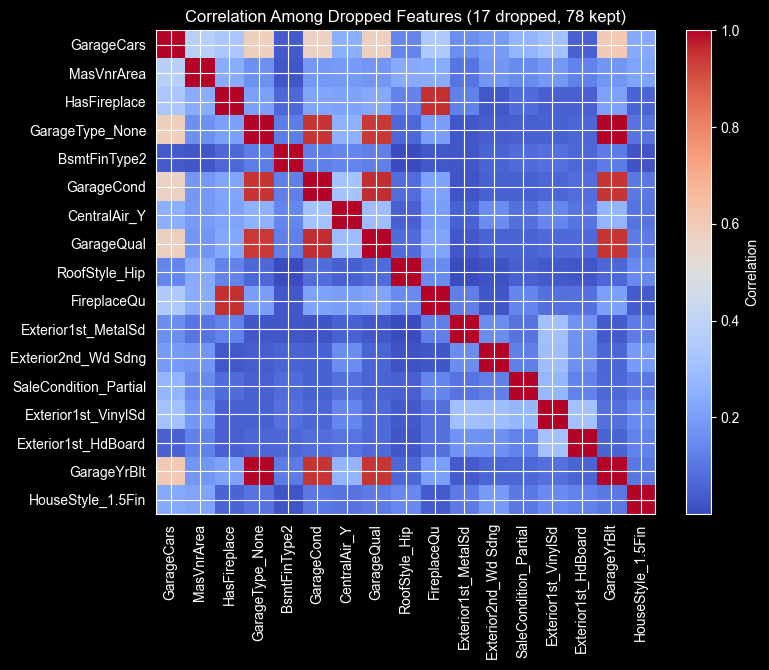

In [37]:
corr_filter = CorrelationFilter(threshold=0.85)
corr_filter.fit(X_train)

dropped_cols = list(corr_filter.features_to_drop)
corr_matrix  = X_train.corr().abs()

print("Dropped features and their partners:\n")
for dropped in corr_filter.features_to_drop:
    partners = corr_matrix[dropped][corr_matrix[dropped] > 0.85]
    partners = partners.drop(dropped, errors='ignore')

    for partner, val in partners.items():
        print(f"  {dropped} - {partner}: {val:.2f}")

dropped_corr = corr_matrix.loc[dropped_cols, dropped_cols]

plt.figure(figsize=(max(8, len(dropped_cols) * 0.4), max(6, len(dropped_cols) * 0.4)))
plt.imshow(dropped_corr.values, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(dropped_cols)), dropped_cols, rotation=90)
plt.yticks(range(len(dropped_cols)), dropped_cols)
plt.title(f'Correlation Among Dropped Features ({len(dropped_cols)} dropped, {len(corr_filter.selected_features)} kept)')
plt.tight_layout()
plt.show()

# Linear Models

In [229]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

strategies = [
    ("corr_filter", CorrelationFilter(threshold=0.85)),
    ("rfe_40",      RFESelector(n_features_to_select=40)),
    ("iv_filter",   IVSelector(threshold=0.02)),
]

models = [
    ("LinearRegression",  LinearRegression(), {}),
    ("Ridge_0.1",         Ridge(alpha=0.1),   {"alpha": 0.1}),
    ("Ridge_1",           Ridge(alpha=1.0),   {"alpha": 1.0}),
    ("Ridge_10",          Ridge(alpha=10),    {"alpha": 10}),
    ("Ridge_100",         Ridge(alpha=100),   {"alpha": 100}),
    ("Ridge_1000",        Ridge(alpha=1000),  {"alpha": 1000}),
    ("Lasso_0.001",       Lasso(alpha=0.001), {"alpha": 0.001}),
    ("Lasso_0.01",        Lasso(alpha=0.01),  {"alpha": 0.01}),
    ("Lasso_0.1",         Lasso(alpha=0.1),   {"alpha": 0.1}),
    ("Lasso_1",           Lasso(alpha=1.0),   {"alpha": 1.0}),
    ("ElasticNet_l1_0.2", ElasticNet(alpha=0.01, l1_ratio=0.2), {"alpha": 0.01, "l1_ratio": 0.2}),
    ("ElasticNet_l1_0.5", ElasticNet(alpha=0.01, l1_ratio=0.5), {"alpha": 0.01, "l1_ratio": 0.5}),
    ("ElasticNet_l1_0.8", ElasticNet(alpha=0.01, l1_ratio=0.8), {"alpha": 0.01, "l1_ratio": 0.8}),
]


mlflow.set_experiment("linear_models")

for strategy_name, selector in strategies:
    for model_name, model, extra_params in models:
        run_name = f"{strategy_name}__{model_name}"

        pipe = Pipeline([
            ("selector", selector),
            ("scaler",   StandardScaler()),
            ("model",    model),
        ])

        with mlflow.start_run(run_name=run_name):
            pipe.fit(X_train, y_train_log)

            train_pred_log = pipe.predict(X_train)
            test_pred_log  = pipe.predict(X_test)

            train_pred = np.expm1(train_pred_log)
            test_pred  = np.expm1(test_pred_log)

            train_rmse     = np.sqrt(mean_squared_error(y_train, train_pred))
            test_rmse      = np.sqrt(mean_squared_error(y_test, test_pred))
            train_rmse_log = np.sqrt(mean_squared_error(y_train_log,train_pred_log))
            test_rmse_log  = np.sqrt(mean_squared_error(y_test_log, test_pred_log))
            gap            = test_rmse - train_rmse
            n_feats        = pipe.named_steps["selector"].transform(X_train).shape[1]

            mlflow.set_tag("model_family",       "linear")
            mlflow.set_tag("selection_strategy", strategy_name)

            mlflow.log_params({
                "model_type": model_name,
                "selection":  strategy_name,
                "n_train":    X_train.shape[0],
                "n_features": n_feats,
                "scaler":     "StandardScaler",
                **extra_params,
            })

            mlflow.log_metrics({
                "train_rmse":     train_rmse,
                "test_rmse":      test_rmse,
                "gap":            gap,
                "train_rmse_log": train_rmse_log,
                "test_rmse_log":  test_rmse_log,
                "train_mae":      mean_absolute_error(y_train, train_pred),
                "test_mae":       mean_absolute_error(y_test,  test_pred),
                "train_r2":       r2_score(y_train, train_pred),
                "test_r2":        r2_score(y_test,  test_pred),
            })

            mlflow.sklearn.log_model(pipe, "pipeline")

        print(f"{run_name:<30} | Feats: {n_feats:<3} | Train: ${train_rmse:,.0f} | Test: ${test_rmse:,.0f} | Gap: ${gap:,.0f}")

2026/04/10 19:13:22 INFO mlflow.tracking.fluent: Experiment with name 'linear_models' does not exist. Creating a new experiment.
2026/04/10 19:13:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 19:13:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run corr_filter__LinearRegression at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0/runs/e147b7a1ff8d4bc8bb887c815ca031e1
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0
corr_filter__LinearRegression  | Feats: 78  | Train: $27,254 | Test: $27,684 | Gap: $431


2026/04/10 19:13:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 19:14:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run corr_filter__Ridge_0.1 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0/runs/b38c2204f2f44efb96a9c0b9ac0245a1
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0
corr_filter__Ridge_0.1         | Feats: 78  | Train: $27,254 | Test: $27,684 | Gap: $430


2026/04/10 19:14:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 19:14:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

🏃 View run iv_filter__ElasticNet_l1_0.2 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0/runs/0aecbcb0f2864c0d90a1d60095467625
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0
iv_filter__ElasticNet_l1_0.2   | Feats: 82  | Train: $27,162 | Test: $27,900 | Gap: $737


2026/04/10 19:30:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 19:30:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run iv_filter__ElasticNet_l1_0.5 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0/runs/87f1853ff6f14a82a11a4af35a5f8ea2
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0
iv_filter__ElasticNet_l1_0.5   | Feats: 82  | Train: $27,652 | Test: $28,455 | Gap: $803


2026/04/10 19:31:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 19:31:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run iv_filter__ElasticNet_l1_0.8 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0/runs/4f449aa5a7624c32b2d350c6b051e911
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/0
iv_filter__ElasticNet_l1_0.8   | Feats: 82  | Train: $28,114 | Test: $29,192 | Gap: $1,078


In [42]:
import warnings
import logging
logging.getLogger("mlflow").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning, module="mlflow")

In [240]:
from sklearn.model_selection import KFold, cross_val_predict

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mlflow.set_experiment("cross_validated_linear_models")

for strategy_name, selector in strategies:
    for model_name, model, extra_params in models:
        run_name = f"{strategy_name}__{model_name}"

        pipe = Pipeline([
            ("selector", selector),
            ("scaler",   StandardScaler()),
            ("model",    model),
        ])

        with mlflow.start_run(run_name=run_name):
            cv_pred_log = cross_val_predict(pipe, X_train, y_train_log, cv=kf)
            cv_pred  = np.expm1(cv_pred_log)
            cv_rmse   = np.sqrt(mean_squared_error(y_train, cv_pred))
            cv_rmse_log = np.sqrt(mean_squared_error(y_train_log, cv_pred_log))

            pipe.fit(X_train, y_train_log)
            test_pred_log = pipe.predict(X_test)
            test_pred  = np.expm1(test_pred_log)

            test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
            test_rmse_log = np.sqrt(mean_squared_error(y_test_log, test_pred_log))

            gap = test_rmse - cv_rmse
            n_feats = pipe.named_steps["selector"].transform(X_train).shape[1]

            mlflow.set_tag("model_family", "linear")
            mlflow.set_tag("selection_strategy", strategy_name)

            mlflow.log_params({
                "model_type": model_name,
                "selection":  strategy_name,
                "n_train":    X_train.shape[0],
                "n_features": n_feats,
                "scaler":     "StandardScaler",
                "cv_folds":   5,
                **extra_params,
            })

            mlflow.log_metrics({
                "cv_rmse":        cv_rmse,
                "test_rmse":      test_rmse,
                "gap":            gap,
                "cv_rmse_log":    cv_rmse_log,
                "test_rmse_log":  test_rmse_log,
                "cv_mae":         mean_absolute_error(y_train, cv_pred),
                "test_mae":       mean_absolute_error(y_test,  test_pred),
                "cv_r2":          r2_score(y_train, cv_pred),
                "test_r2":        r2_score(y_test,  test_pred),
            })

            mlflow.sklearn.log_model(model, name="model")

        print(f"{run_name:<30} | Feats: {n_feats:<3} | CV: ${cv_rmse:,.0f} | Test: ${test_rmse:,.0f} | Gap: ${gap:,.0f}")


🏃 View run corr_filter__LinearRegression at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/1/runs/7be1c9c8bc2a4714b492e3a2cd7b849e
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/1
corr_filter__LinearRegression  | Feats: 78  | CV: $30,997 | Test: $27,684 | Gap: $-3,313
🏃 View run corr_filter__Ridge_0.1 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/1/runs/af556a8a1b5248efa462197f07a54908
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/1
corr_filter__Ridge_0.1         | Feats: 78  | CV: $30,995 | Test: $27,684 | Gap: $-3,310
🏃 View run corr_filter__Ridge_1 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/1/runs/e34306f4b3844ce78e1c95a4a0ddeae4
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/1
corr_filter__Ridge_1           | Feats: 78  | CV: $30,978 | Test: $27,686 | Gap: $-3,292
🏃 View run corr_filter__Ridge_10 at: https://dagshub.com/aochi

In [38]:
client = mlflow.tracking.MlflowClient()

linear_runs = client.search_runs(
    experiment_ids=[client.get_experiment_by_name("cross_validated_linear_models").experiment_id],
    order_by=["metrics.test_rmse ASC"],
    max_results=15
)

print("Top 15 Linear Models:")
for run in linear_runs:
    print(f"  {run.info.run_name:50s} | test_rmse: ${run.data.metrics['test_rmse']:,.0f} | "
          f"selection: {run.data.params.get('selection')} | "
          f"n_features: {run.data.params.get('n_features')}")


Top 15 Linear Models:
  iv_filter__Ridge_10                                | test_rmse: $27,623 | selection: iv_filter | n_features: 82
  corr_filter__Lasso_0.001                           | test_rmse: $27,656 | selection: corr_filter | n_features: 78
  corr_filter__LinearRegression                      | test_rmse: $27,684 | selection: corr_filter | n_features: 78
  corr_filter__LinearRegression                      | test_rmse: $27,684 | selection: corr_filter | n_features: 78
  corr_filter__Ridge_0.1                             | test_rmse: $27,684 | selection: corr_filter | n_features: 78
  corr_filter__Ridge_0.1                             | test_rmse: $27,684 | selection: corr_filter | n_features: 78
  corr_filter__Ridge_1                               | test_rmse: $27,686 | selection: corr_filter | n_features: 78
  corr_filter__Ridge_1                               | test_rmse: $27,686 | selection: corr_filter | n_features: 78
  iv_filter__Lasso_0.001                            

In [54]:
def train_and_log(pipe, X_train, X_test, y_train, y_test,
                  y_train_log, y_test_log, run_name, tags, params):

    with mlflow.start_run(run_name=run_name):
        cv_pred_log = cross_val_predict(pipe, X_train, y_train_log, cv=kf)
        cv_pred = np.expm1(cv_pred_log)
        cv_rmse = np.sqrt(mean_squared_error(y_train, cv_pred))
        cv_rmse_log = np.sqrt(mean_squared_error(y_train_log, cv_pred_log))

        pipe.fit(X_train, y_train_log)
        test_pred_log = pipe.predict(X_test)
        test_pred = np.expm1(test_pred_log)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        test_rmse_log = np.sqrt(mean_squared_error(y_test_log, test_pred_log))

        gap = test_rmse - cv_rmse
        if "selector" in pipe.named_steps:
            n_feats = pipe.named_steps["selector"].transform(X_train).shape[1]
        else:
            n_feats = X_train.shape[1]

        for k, v in tags.items():
            mlflow.set_tag(k, v)

        mlflow.log_params({**params, "n_features": n_feats})

        mlflow.log_metrics({
            "cv_rmse":      cv_rmse,
            "test_rmse":    test_rmse,
            "gap":          gap,
            "cv_rmse_log":  cv_rmse_log,
            "test_rmse_log":test_rmse_log,
            "cv_mae":       mean_absolute_error(y_train, cv_pred),
            "test_mae":     mean_absolute_error(y_test,  test_pred),
            "cv_r2":        r2_score(y_train, cv_pred),
            "test_r2":      r2_score(y_test,  test_pred),
        })

        mlflow.sklearn.log_model(pipe, name="model")

    print(f"{run_name:<35} | Feats: {n_feats:<3} | CV: ${cv_rmse:,.0f} | Test: ${test_rmse:,.0f} | Gap: ${gap:,.0f}")
    return cv_rmse, test_rmse, gap

# Decision Tree Models

In [247]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeRegressor

strategies = [
    ("no_selection",  FunctionTransformer()),
    ("corr_filter", CorrelationFilter(threshold=0.85)),
    ("iv_filter",   IVSelector(threshold=0.02)),
]

models = [
    ("DT_depth3",  DecisionTreeRegressor(max_depth=3),  {"max_depth": 3,    "min_samples_leaf": 1}),
    ("DT_depth5",  DecisionTreeRegressor(max_depth=5),  {"max_depth": 5,    "min_samples_leaf": 1}),
    ("DT_depth10", DecisionTreeRegressor(max_depth=10), {"max_depth": 10,   "min_samples_leaf": 1}),
    ("DT_depth15", DecisionTreeRegressor(max_depth=15), {"max_depth": 15,   "min_samples_leaf": 1}),
    ("DT_depthN",  DecisionTreeRegressor(max_depth=None),{"max_depth": None, "min_samples_leaf": 1}),

    ("DT_d5_leaf5",  DecisionTreeRegressor(max_depth=5, min_samples_leaf=5),  {"max_depth": 5, "min_samples_leaf": 5}),
    ("DT_d5_leaf10", DecisionTreeRegressor(max_depth=5, min_samples_leaf=10), {"max_depth": 5, "min_samples_leaf": 10}),
    ("DT_d5_leaf20", DecisionTreeRegressor(max_depth=5, min_samples_leaf=20), {"max_depth": 5, "min_samples_leaf": 20}),
    ("DT_d10_leaf5",  DecisionTreeRegressor(max_depth=10, min_samples_leaf=5),  {"max_depth": 10, "min_samples_leaf": 5}),
    ("DT_d10_leaf10", DecisionTreeRegressor(max_depth=10, min_samples_leaf=10), {"max_depth": 10, "min_samples_leaf": 10}),
]

mlflow.set_experiment("cross_validated_decision_tree_models")

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

for strategy_name, selector in strategies:
    for model_name, model, extra_params in models:

        pipe = Pipeline([
            ("selector", selector),
            ("scaler",   StandardScaler()),
            ("model",    model),
        ])

        train_and_log(
            pipe        = pipe,
            X_train     = X_train,
            X_test      = X_test,
            y_train     = y_train,
            y_test      = y_test,
            y_train_log = y_train_log,
            y_test_log  = y_test_log,
            run_name    = f"{strategy_name}__{model_name}",
            tags        = {"model_family": "tree", "selection_strategy": strategy_name},
            params      = {"model_type": "DecisionTree", "selection": strategy_name,
                           "n_train": X_train.shape[0], "cv_folds": 5, **extra_params},
        )

🏃 View run no_selection__DT_depth3 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/2/runs/d5a5e2d79b174069bc6d6e75dc7fddd3
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/2
no_selection__DT_depth3             | Feats: 95  | CV: $45,394 | Test: $48,654 | Gap: $3,260
🏃 View run no_selection__DT_depth5 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/2/runs/c85a1c60cc66485285963e6cfd0af5a6
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/2
no_selection__DT_depth5             | Feats: 95  | CV: $42,401 | Test: $40,091 | Gap: $-2,310
🏃 View run no_selection__DT_depth10 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/2/runs/0a649e02971c4684afb7eaae7ac756db
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/2
no_selection__DT_depth10            | Feats: 95  | CV: $44,751 | Test: $34,680 | Gap: $-10,070
🏃 View run no_selection__DT_depth15 at: https://

In [40]:
client = mlflow.tracking.MlflowClient()

linear_runs = client.search_runs(
    experiment_ids=[client.get_experiment_by_name("cross_validated_decision_tree_models").experiment_id],
    order_by=["metrics.test_rmse ASC"],
    max_results=15
)

print("Top 15 Decision Tree Models:")
for run in linear_runs:
    print(f"  {run.info.run_name:50s} | test_rmse: ${run.data.metrics['test_rmse']:,.0f} | "
          f"selection: {run.data.params.get('selection')} | "
          f"n_features: {run.data.params.get('n_features')}")


Top 15 Decision Tree Models:
  no_selection__DT_depth10                           | test_rmse: $34,680 | selection: no_selection | n_features: 95
  iv_filter__DT_depth10                              | test_rmse: $35,481 | selection: iv_filter | n_features: 82
  corr_filter__DT_d10_leaf10                         | test_rmse: $35,620 | selection: corr_filter | n_features: 78
  corr_filter__DT_d10_leaf5                          | test_rmse: $35,794 | selection: corr_filter | n_features: 78
  no_selection__DT_depthN                            | test_rmse: $36,484 | selection: no_selection | n_features: 95
  iv_filter__DT_d10_leaf5                            | test_rmse: $36,620 | selection: iv_filter | n_features: 82
  no_selection__DT_d10_leaf5                         | test_rmse: $36,622 | selection: no_selection | n_features: 95
  corr_filter__DT_d5_leaf5                           | test_rmse: $36,728 | selection: corr_filter | n_features: 78
  iv_filter__DT_depthN                      

# Random Forest Models

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

strategies = [
    ("no_selection", FunctionTransformer()),
    ("corr_filter",  CorrelationFilter(threshold=0.85)),
]

models = [
    ("RF_100_depthN",   RandomForestRegressor(n_estimators=100, max_depth=None,  random_state=42), {"n_estimators": 100, "max_depth": None}),
    ("RF_100_depth10",  RandomForestRegressor(n_estimators=100, max_depth=10,    random_state=42), {"n_estimators": 100, "max_depth": 10}),
    ("RF_100_depth15",  RandomForestRegressor(n_estimators=100, max_depth=15,    random_state=42), {"n_estimators": 100, "max_depth": 15}),
    ("RF_200_depthN",   RandomForestRegressor(n_estimators=200, max_depth=None,  random_state=42), {"n_estimators": 200, "max_depth": None}),
    ("RF_100_feat_sqrt",RandomForestRegressor(n_estimators=100, max_features="sqrt", random_state=42), {"n_estimators": 100, "max_features": "sqrt"}),
    ("RF_100_feat_03",  RandomForestRegressor(n_estimators=100, max_features=0.3,    random_state=42), {"n_estimators": 100, "max_features": 0.3}),
]

mlflow.set_experiment("cross_validated_random_forest_models")

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for strategy_name, selector in strategies:
    for model_name, model, extra_params in models:
        pipe = Pipeline([
            ("selector", selector),
            ("scaler",   StandardScaler()),
            ("model",    model),
        ])

        train_and_log(
            pipe        = pipe,
            X_train     = X_train,
            X_test      = X_test,
            y_train     = y_train,
            y_test      = y_test,
            y_train_log = y_train_log,
            y_test_log  = y_test_log,
            run_name    = f"{strategy_name}__{model_name}",
            tags        = {"model_family": "random_forest", "selection_strategy": strategy_name},
            params      = {"model_type": "RandomForest", "selection": strategy_name,
                           "n_train": X_train.shape[0], "cv_folds": 5, **extra_params},
        )

🏃 View run no_selection__RF_100_depthN at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3/runs/2dd295fb9f284ec4a0c7ffa6aec94730
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3
no_selection__RF_100_depthN         | Feats: 95  | CV: $30,963 | Test: $29,081 | Gap: $-1,883
🏃 View run no_selection__RF_100_depth10 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3/runs/dcf7474f9ce946c3b9f2162638d79232
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3
no_selection__RF_100_depth10        | Feats: 95  | CV: $31,072 | Test: $29,021 | Gap: $-2,051
🏃 View run no_selection__RF_100_depth15 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3/runs/9fc2b78fe88341bdb21705388779e316
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3
no_selection__RF_100_depth15        | Feats: 95  | CV: $31,141 | Test: $29,100 | Gap: $-2,041
🏃 View run no_selection__RF_200_dep

In [50]:
client = mlflow.tracking.MlflowClient()

linear_runs = client.search_runs(
    experiment_ids=[client.get_experiment_by_name("cross_validated_random_forest_models").experiment_id],
    order_by=["metrics.test_rmse ASC"],
    max_results=10
)

print("Top 10 Random Forest Models:")
for run in linear_runs:
    print(f"  {run.info.run_name:50s} | test_rmse: ${run.data.metrics['test_rmse']:,.0f} | "
          f"selection: {run.data.params.get('selection')} | "
          f"n_features: {run.data.params.get('n_features')}")


Top 10 Random Forest Models:
  corr_filter__RF_100_depthN                         | test_rmse: $28,197 | selection: corr_filter | n_features: 78
  corr_filter__RF_200_depthN                         | test_rmse: $28,531 | selection: corr_filter | n_features: 78
  corr_filter__RF_100_depth10                        | test_rmse: $28,586 | selection: corr_filter | n_features: 78
  no_selection__RF_100_feat_03                       | test_rmse: $28,844 | selection: no_selection | n_features: 95
  corr_filter__RF_100_depth15                        | test_rmse: $29,013 | selection: corr_filter | n_features: 78
  no_selection__RF_100_depth10                       | test_rmse: $29,021 | selection: no_selection | n_features: 95
  no_selection__RF_200_depthN                        | test_rmse: $29,065 | selection: no_selection | n_features: 95
  no_selection__RF_100_depthN                        | test_rmse: $29,081 | selection: no_selection | n_features: 95
  no_selection__RF_100_depth15         

In [52]:
strategies = [
    ("corr_filter", CorrelationFilter(threshold=0.85)),
]

models = [
    ("RF_300_depthN", RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42),
     {"n_estimators": 300, "max_depth": None}),

    ("RF_100_feat_05", RandomForestRegressor(n_estimators=100, max_features=0.5, random_state=42),
     {"n_estimators": 100, "max_features": 0.5}),
    ("RF_100_feat_07", RandomForestRegressor(n_estimators=100, max_features=0.7, random_state=42),
     {"n_estimators": 100, "max_features": 0.7}),

    ("RF_100_leaf2", RandomForestRegressor(n_estimators=100, min_samples_leaf=2, random_state=42),
     {"n_estimators": 100, "min_samples_leaf": 2}),
    ("RF_100_leaf3", RandomForestRegressor(n_estimators=100, min_samples_leaf=3, random_state=42),
     {"n_estimators": 100, "min_samples_leaf": 3}),

    ("RF_200_feat_07_leaf2", RandomForestRegressor(n_estimators=200, max_features=0.7, min_samples_leaf=2, random_state=42),
     {"n_estimators": 200, "max_features": 0.7, "min_samples_leaf": 2}),
]

for strategy_name, selector in strategies:
    for model_name, model, extra_params in models:
        pipe = Pipeline([
            ("selector", selector),
            ("scaler",   StandardScaler()),
            ("model",    model),
        ])

        train_and_log(
            pipe        = pipe,
            X_train     = X_train,
            X_test      = X_test,
            y_train     = y_train,
            y_test      = y_test,
            y_train_log = y_train_log,
            y_test_log  = y_test_log,
            run_name    = f"{strategy_name}__{model_name}",
            tags        = {"model_family": "random_forest", "selection_strategy": strategy_name},
            params      = {"model_type": "RandomForest", "selection": strategy_name,
                           "n_train": X_train.shape[0], "cv_folds": 5, **extra_params},
        )

🏃 View run corr_filter__RF_300_depthN at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3/runs/64e0449bb08147f791d5e04e4b50c744
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3
corr_filter__RF_300_depthN          | Feats: 78  | CV: $30,660 | Test: $28,693 | Gap: $-1,967
🏃 View run corr_filter__RF_100_feat_05 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3/runs/8904a8586c914823814a790e861e58ed
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3
corr_filter__RF_100_feat_05         | Feats: 78  | CV: $29,706 | Test: $27,994 | Gap: $-1,712
🏃 View run corr_filter__RF_100_feat_07 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3/runs/54da3a6e6102425d9b0fac0e47abdd29
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/3
corr_filter__RF_100_feat_07         | Feats: 78  | CV: $29,984 | Test: $28,389 | Gap: $-1,595
🏃 View run corr_filter__RF_100_leaf2 a

In [53]:
client = mlflow.tracking.MlflowClient()

linear_runs = client.search_runs(
    experiment_ids=[client.get_experiment_by_name("cross_validated_random_forest_models").experiment_id],
    order_by=["metrics.test_rmse ASC"],
    max_results=10
)

print("Top 10 Random Forest Models:")
for run in linear_runs:
    print(f"  {run.info.run_name:50s} | test_rmse: ${run.data.metrics['test_rmse']:,.0f} | "
          f"selection: {run.data.params.get('selection')} | "
          f"n_features: {run.data.params.get('n_features')}")


Top 10 Random Forest Models:
  corr_filter__RF_100_feat_05                        | test_rmse: $27,994 | selection: corr_filter | n_features: 78
  corr_filter__RF_100_depthN                         | test_rmse: $28,197 | selection: corr_filter | n_features: 78
  corr_filter__RF_100_feat_07                        | test_rmse: $28,389 | selection: corr_filter | n_features: 78
  corr_filter__RF_100_leaf2                          | test_rmse: $28,440 | selection: corr_filter | n_features: 78
  corr_filter__RF_200_feat_07_leaf2                  | test_rmse: $28,481 | selection: corr_filter | n_features: 78
  corr_filter__RF_200_depthN                         | test_rmse: $28,531 | selection: corr_filter | n_features: 78
  corr_filter__RF_100_depth10                        | test_rmse: $28,586 | selection: corr_filter | n_features: 78
  corr_filter__RF_100_leaf3                          | test_rmse: $28,623 | selection: corr_filter | n_features: 78
  corr_filter__RF_300_depthN               

# Stacking Models

In [56]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

estimators = [
    ("ridge_10_iv", Pipeline([
        ("selector", IVSelector(threshold=0.02)),
        ("scaler",   StandardScaler()),
        ("model",    Ridge(alpha=10)),
    ])),
    ("lasso_001_corr", Pipeline([
        ("selector", CorrelationFilter(threshold=0.85)),
        ("scaler",   StandardScaler()),
        ("model",    Lasso(alpha=0.001)),
    ])),
    ("lr_corr", Pipeline([
        ("selector", CorrelationFilter(threshold=0.85)),
        ("scaler",   StandardScaler()),
        ("model",    LinearRegression()),
    ])),
    ("rf_feat05_corr", Pipeline([
        ("selector", CorrelationFilter(threshold=0.85)),
        ("scaler",   StandardScaler()),
        ("model",    RandomForestRegressor(n_estimators=100, max_features=0.5, random_state=42)),
    ])),
    ("rf_depthN_corr", Pipeline([
        ("selector", CorrelationFilter(threshold=0.85)),
        ("scaler",   StandardScaler()),
        ("model",    RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)),
    ])),
    ("rf_feat07_corr", Pipeline([
        ("selector", CorrelationFilter(threshold=0.85)),
        ("scaler",   StandardScaler()),
        ("model",    RandomForestRegressor(n_estimators=100, max_features=0.7, random_state=42)),
    ])),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=10),
    cv=5,
)

mlflow.set_experiment("stacking_models")

train_and_log(
    pipe        = Pipeline([("model", stack)]),
    X_train     = X_train,
    X_test      = X_test,
    y_train     = y_train,
    y_test      = y_test,
    y_train_log = y_train_log,
    y_test_log  = y_test_log,
    run_name    = "stack_top3linear_top3rf",
    tags        = {"model_family": "stacking"},
    params      = {"meta_learner": "Ridge_10", "n_base_learners": 6},
)

🏃 View run stack_top3linear_top3rf at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/4/runs/1cb7e8b022484ffdae0b6499da49f851
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/4
stack_top3linear_top3rf             | Feats: 95  | CV: $27,975 | Test: $25,867 | Gap: $-2,108


(np.float64(27974.62321404792),
 np.float64(25866.55974074251),
 np.float64(-2108.0634733054103))

In [57]:
stack = StackingRegressor(
    estimators=[
        ("ridge_10_iv", Pipeline([
            ("selector", IVSelector(threshold=0.02)),
            ("scaler",   StandardScaler()),
            ("model",    Ridge(alpha=10)),
        ])),
        ("rf_feat05_corr", Pipeline([
            ("selector", CorrelationFilter(threshold=0.85)),
            ("scaler",   StandardScaler()),
            ("model",    RandomForestRegressor(n_estimators=100, max_features=0.5, random_state=42)),
        ])),
    ],
    final_estimator=Ridge(alpha=10),
    cv=5,
)

mlflow.set_experiment("stacking_models")

train_and_log(
    pipe        = Pipeline([("model", stack)]),
    X_train     = X_train,
    X_test      = X_test,
    y_train     = y_train,
    y_test      = y_test,
    y_train_log = y_train_log,
    y_test_log  = y_test_log,
    run_name    = "stack_ridge10_rf_feat05",
    tags        = {"model_family": "stacking"},
    params      = {"meta_learner": "Ridge_10", "n_base_learners": 2},
)

🏃 View run stack_ridge10_rf_feat05 at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/4/runs/caffb4c48d6843f684d241fc0ed4a445
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/4
stack_ridge10_rf_feat05             | Feats: 95  | CV: $28,083 | Test: $26,566 | Gap: $-1,517


(np.float64(28083.435786877497),
 np.float64(26565.985340676012),
 np.float64(-1517.4504462014847))

In [58]:
client = mlflow.tracking.MlflowClient()

linear_runs = client.search_runs(
    experiment_ids=[client.get_experiment_by_name("stacking_models").experiment_id],
    order_by=["metrics.test_rmse ASC"],
    max_results=10
)

print("Top 2 Stacking Models:")
for run in linear_runs:
    print(f"  {run.info.run_name:50s} | test_rmse: ${run.data.metrics['test_rmse']:,.0f} | "
          f"selection: {run.data.params.get('selection')} | "
          f"n_features: {run.data.params.get('n_features')}")


Top 2 Stacking Models:
  stack_top3linear_top3rf                            | test_rmse: $25,867 | selection: None | n_features: 95
  stack_ridge10_rf_feat05                            | test_rmse: $26,566 | selection: None | n_features: 95


# Register Best Model

In [62]:
import skops.io as sio
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

stack = StackingRegressor(
    estimators=[
        ("ridge_10_iv", Pipeline([
            ("selector", IVSelector(threshold=0.02)),
            ("scaler",   StandardScaler()),
            ("model",    Ridge(alpha=10)),
        ])),
        ("lasso_001_corr", Pipeline([
            ("selector", CorrelationFilter(threshold=0.85)),
            ("scaler",   StandardScaler()),
            ("model",    Lasso(alpha=0.001)),
        ])),
        ("lr_corr", Pipeline([
            ("selector", CorrelationFilter(threshold=0.85)),
            ("scaler",   StandardScaler()),
            ("model",    LinearRegression()),
        ])),
        ("rf_feat05_corr", Pipeline([
            ("selector", CorrelationFilter(threshold=0.85)),
            ("scaler",   StandardScaler()),
            ("model",    RandomForestRegressor(n_estimators=100, max_features=0.5, random_state=42)),
        ])),
        ("rf_depthN_corr", Pipeline([
            ("selector", CorrelationFilter(threshold=0.85)),
            ("scaler",   StandardScaler()),
            ("model",    RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)),
        ])),
        ("rf_feat07_corr", Pipeline([
            ("selector", CorrelationFilter(threshold=0.85)),
            ("scaler",   StandardScaler()),
            ("model",    RandomForestRegressor(n_estimators=100, max_features=0.7, random_state=42)),
        ])),
    ],
    final_estimator=Ridge(alpha=10),
    cv=5,
)

pipe = Pipeline([("model", stack)])

mlflow.set_experiment("stacking_models")

with mlflow.start_run(run_name="stack_top3linear_top3rf_final"):
    cv_pred_log = cross_val_predict(pipe, X_train, y_train_log, cv=kf)
    cv_pred = np.expm1(cv_pred_log)
    cv_rmse = np.sqrt(mean_squared_error(y_train, cv_pred))

    pipe.fit(X_train, y_train_log)

    test_pred_log = pipe.predict(X_test)
    test_pred = np.expm1(test_pred_log)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    gap = test_rmse - cv_rmse

    mlflow.set_tag("model_family", "stacking")
    mlflow.log_params({
        "meta_learner":    "Ridge_10",
        "n_base_learners": 6,
        "cv_folds":        5,
    })
    mlflow.log_metrics({
        "cv_rmse":   cv_rmse,
        "test_rmse": test_rmse,
        "gap":       gap,
        "test_mae":  mean_absolute_error(y_test, test_pred),
        "test_r2":   r2_score(y_test, test_pred),
    })

    sio.dump(pipe, "best_model.skops")
    mlflow.log_artifact("best_model.skops")

    run_id = mlflow.active_run().info.run_id
    print(f"Run ID: {run_id}")

print(f"CV: ${cv_rmse:,.0f} | Test: ${test_rmse:,.0f} | Gap: ${gap:,.0f}")

Run ID: 9fb4f8f3dca94ea4860ab7f31e305909
🏃 View run stack_top3linear_top3rf_final at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/4/runs/9fb4f8f3dca94ea4860ab7f31e305909
🧪 View experiment at: https://dagshub.com/aochi23/ml_assn_01.mlflow/#/experiments/4
CV: $27,975 | Test: $25,867 | Gap: $-2,108


In [63]:
artifacts = client.list_artifacts(run_id)
for a in artifacts:
    print(a.path)

best_model.skops


In [64]:
client = mlflow.tracking.MlflowClient()

client.create_registered_model("house_price_stacking_best_model")

version = client.create_model_version(
    name="house_price_stacking_best_model",
    source=f"runs:/{run_id}/best_model.skops",
    run_id=run_id
)

print("Version:", version.version)
print("Status:", version.status)

Version: 1
Status: READY


In [66]:
client = mlflow.tracking.MlflowClient()

runs = client.search_runs(
    experiment_ids=[client.get_experiment_by_name("stacking_models").experiment_id],
    order_by=["metrics.test_rmse ASC"],
)

for run in runs:
    print(run.info.run_name, '|', run.info.run_id)

stack_top3linear_top3rf_final | 9fb4f8f3dca94ea4860ab7f31e305909
stack_top3linear_top3rf | 1cb7e8b022484ffdae0b6499da49f851
stack_ridge10_rf_feat05 | caffb4c48d6843f684d241fc0ed4a445


In [67]:
best_run_id = '1cb7e8b022484ffdae0b6499da49f851'

client.create_registered_model("house_price_stacking_best_model_v2")

version = client.create_model_version(
    name="house_price_stacking_best_model_v2",
    source=f"runs:/{best_run_id}/model",
    run_id=best_run_id
)
print("Version:", version.version)

Version: 1
